In [1]:
from py_isru.lib.isru_plant import ISRUPlant, PlantSpecification, ISRUPlantState
from py_isru.lib.environment import MarsEnvironment, MarsEnvironmentSpecification, MarsEnvironmentState
from py_isru.lib.sabatier_reactor import SabatierSpecification
from py_isru.lib.electrolysis_reactor import ElectrolysisSpecification
from py_isru.lib.storage_tank import TankSpecification
from py_isru.lib.power_system import SolarArraySpecification, SolarPanelSpecification, BatterySpecification, KrustySpecification
from py_isru.lib.reactor import ResourceType
from math import radians

sabatier_spec = SabatierSpecification(
    volume_m3=1.0,
    max_temperature_K=1000.0,
    max_pressure_Pa=5e6,
    thermal_mass_J_per_K=1e4,
    heat_loss_coefficient_W_per_m2K=10.0,
    surface_area_m2=5.0,
    catalyst_type="Ru/Al2O3",
    catalyst_loading_kg_per_m3=50.0,
    catalyst_surface_area_m2_per_kg=100.0,
    catalyst_porosity=0.4
)

electrolysis_spec = ElectrolysisSpecification(
    volume_m3=1.0,
    max_temperature_K=1000.0,
    max_pressure_Pa=5e6,
    thermal_mass_J_per_K=1e4,
    heat_loss_coefficient_W_per_m2K=10.0,
    surface_area_m2=5.0,
    membrane_type="Nafion",
    membrane_thickness_m=0.0002,
    membrane_conductivity_S_per_m=10.0,
    electrode_area_m2=1.0,
    max_current_density_A_per_m2=1000.0,
    max_power_W=10000.0
)

tank_specs = {
    ResourceType.CO2: TankSpecification(
        volume_m3=2.0,
        max_pressure_Pa=5e6,
        max_temperature_K=1000.0,
        material="Stainless Steel 316",
        wall_thickness_m=0.01,
        thermal_conductivity_W_per_mK=15.0,
        safety_factor=2.0
    ),
    ResourceType.H2: TankSpecification(
        volume_m3=2.0,
        max_pressure_Pa=5e6,
        max_temperature_K=1000.0,
        material="Stainless Steel 316",
        wall_thickness_m=0.01,
        thermal_conductivity_W_per_mK=15.0,
        safety_factor=2.0
    ),
    ResourceType.O2: TankSpecification(
        volume_m3=2.0,
        max_pressure_Pa=5e6,
        max_temperature_K=1000.0,
        material="Stainless Steel 316",
        wall_thickness_m=0.01,
        thermal_conductivity_W_per_mK=15.0,
        safety_factor=2.0
    ),
    ResourceType.CH4: TankSpecification(
        volume_m3=2.0,
        max_pressure_Pa=5e6,
        max_temperature_K=1000.0,
        material="Stainless Steel 316",
        wall_thickness_m=0.01,
        thermal_conductivity_W_per_mK=15.0,
        safety_factor=2.0
    ),
    ResourceType.H2O: TankSpecification(
        volume_m3=2.0,
        max_pressure_Pa=5e6,
        max_temperature_K=1000.0,
        material="Stainless Steel 316",
        wall_thickness_m=0.01,
        thermal_conductivity_W_per_mK=15.0,
        safety_factor=2.0
    )
}

solar_spec = SolarArraySpecification(
    n_panels=300,
    panel_spec=SolarPanelSpecification(
        area=5.0,
        base_efficiency=0.2,
        max_temp=100.0,
        min_temp=-100.0,
        mass=10.0,
        dust_tolerance=0.5
    )
)

battery_spec = BatterySpecification(
    capacity_wh=10_000.0, 
    max_power=1000.0,
    initial_state_of_charge=0.90  # 20% charged
)

krusty_spec = KrustySpecification(
    nominal_power=15_000.0,  # 9 kW nominal electrical
    max_power=20_000.0,     # 10 kW max electrical
    startup_time=200.0,  # 200 seconds startup (not realistic)
    cooldown_time=200.0, # 200 seconds cooldown (not realistic)
    burn_in_time=200.0  # 200 seconds burn-in (not realistic)
)
    
# Control parameters.
min_tank_levels_mol = {res: 1.0 for res in tank_specs.keys()}
max_tank_levels_mol = {res: 100.0 for res in tank_specs.keys()}
emergency_power_threshold_W = 500.0  # W
maintenance_interval_s = 3600.0  # 1 hour

isru_plant_spec = PlantSpecification(
    sabatier_spec=sabatier_spec,
    electrolysis_spec=electrolysis_spec,
    tank_specs=tank_specs,
    solar_spec=solar_spec,
    battery_spec=battery_spec,
    krusty_spec=krusty_spec,
    min_tank_levels_mol=min_tank_levels_mol,
    max_tank_levels_mol=max_tank_levels_mol,
    emergency_power_threshold_W=emergency_power_threshold_W,
    maintenance_interval_s=maintenance_interval_s
)

env = MarsEnvironment(
    MarsEnvironmentSpecification(
        # Jezero Crater coordinates: 18.4447°N, 77.4508°E
        latitude_rad=radians(18.4447),
        longitude_rad=radians(77.4508),
        altitude_m=-2.5e3,  # Jezero is about 2.5km below Mars reference
    )
)

def isru_plant_state_to_dict(state: ISRUPlantState) -> dict:
    return {
        "total_CH4_produced_mol": state.total_CH4_produced_mol,
        "total_O2_produced_mol": state.total_O2_produced_mol,
        "current_CH4_level_mol": state.current_CH4_level_mol,
        "current_O2_level_mol": state.current_O2_level_mol,
        "current_H2O_level_mol": state.current_H2O_level_mol,
        "current_H2_level_mol": state.current_H2_level_mol,
        "current_CO2_level_mol": state.current_CO2_level_mol,
        "total_energy_consumed_J": state.total_energy_consumed_J,
        "energy_required_W": state.energy_required_W,
        "energy_available_W": state.energy_available_W,
        "error": state.error,
        "warning": state.warning,
        "status": state.status,
        "sabatier_temperature_K": state.sabatier_temperature_K,
        "electrolysis_temperature_K": state.electrolysis_temperature_K,
        "time_elapsed_s": state.time_elapsed_s
    }
    
def env_state_to_dict(state: MarsEnvironmentState) -> dict:
    return {
        "dust_storm": state.dust_storm,
        "dust_opacity_tau": state.dust_opacity_tau,
        "temperature_K": state.temperature_K,
        "wind_speed_m_per_s": state.wind_speed_m_per_s,
        "time_of_day_s": state.time_of_day_s,
        "sols_since_perihelion": state.sols_since_perihelion,
        "solar_intensity_W_per_m2": state.solar_intensity_W_per_m2,
        "sun_azimuth": state.sun_azimuth,
        "sun_elevation": state.sun_elevation,
        "dust_density_kg_per_m3": state.dust_density_kg_per_m3
    }
    
isru_plant = ISRUPlant(isru_plant_spec, env)

import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns

isru_plant_df = pd.DataFrame(isru_plant_state_to_dict(isru_plant.get_state()), index=[0])
environment_df = pd.DataFrame(env_state_to_dict(isru_plant.environment.get_state()), index=[0])
print(isru_plant.spec)
print(isru_plant)

PlantSpecification(sabatier_spec=SabatierSpecification(volume_m3=1.0, max_temperature_K=1000.0, max_pressure_Pa=5000000.0, thermal_mass_J_per_K=10000.0, heat_loss_coefficient_W_per_m2K=10.0, surface_area_m2=5.0, catalyst_type='Ru/Al2O3', catalyst_loading_kg_per_m3=50.0, catalyst_surface_area_m2_per_kg=100.0, catalyst_porosity=0.4, startup_time_s=300.0, shutdown_time_s=300.0), electrolysis_spec=ElectrolysisSpecification(volume_m3=1.0, max_temperature_K=1000.0, max_pressure_Pa=5000000.0, thermal_mass_J_per_K=10000.0, heat_loss_coefficient_W_per_m2K=10.0, surface_area_m2=5.0, membrane_type='Nafion', membrane_thickness_m=0.0002, membrane_conductivity_S_per_m=10.0, electrode_area_m2=1.0, max_current_density_A_per_m2=1000.0, max_power_W=10000.0, startup_time_s=300.0, shutdown_time_s=300.0), tank_specs={CO2: TankSpecification(volume_m3=2.0, max_pressure_Pa=5000000.0, max_temperature_K=1000.0, material='Stainless Steel 316', wall_thickness_m=0.01, thermal_conductivity_W_per_mK=15.0, safety_fac

In [2]:
for resource_type in ResourceType:
    if resource_type in isru_plant.tanks:
        isru_plant.tanks[resource_type].moles = 10.0
        
isru_plant_df = pd.concat([isru_plant_df, pd.DataFrame(isru_plant_state_to_dict(isru_plant.get_state()), index=[isru_plant_df.index[-1] + 1])])
environment_df = pd.concat([environment_df, pd.DataFrame(env_state_to_dict(isru_plant.environment.get_state()), index=[environment_df.index[-1] + 1])])

In [3]:
isru_plant.start()

isru_plant_df = pd.concat([isru_plant_df, pd.DataFrame(isru_plant_state_to_dict(isru_plant.get_state()), index=[isru_plant_df.index[-1] + 1])])
environment_df = pd.concat([environment_df, pd.DataFrame(env_state_to_dict(isru_plant.environment.get_state()), index=[environment_df.index[-1] + 1])])

for _ in range(300):
    isru_plant.step(1)
    isru_plant_df = pd.concat([isru_plant_df, pd.DataFrame(isru_plant_state_to_dict(isru_plant.get_state()), index=[isru_plant_df.index[-1] + 1])])
    environment_df = pd.concat([environment_df, pd.DataFrame(env_state_to_dict(isru_plant.environment.get_state()), index=[environment_df.index[-1] + 1])])

In [4]:
# for _ in range(24):
#     isru_plant.step(60.0 * 60.0)
#     isru_plant_df = pd.concat([isru_plant_df, pd.DataFrame(isru_plant_state_to_dict(isru_plant.get_state()), index=[isru_plant_df.index[-1] + 1])])
#     environment_df = pd.concat([environment_df, pd.DataFrame(env_state_to_dict(isru_plant.environment.get_state()), index=[environment_df.index[-1] + 1])])
    
# isru_plant.shutdown()

In [5]:
isru_plant_df = isru_plant_df[2:]
environment_df = environment_df[2:]

In [6]:
environment_df

,dust_storm,dust_opacity_tau,temperature_K,wind_speed_m_per_s,time_of_day_s,sols_since_perihelion,solar_intensity_W_per_m2,sun_azimuth,sun_elevation,dust_density_kg_per_m3
2,DustStormSeverity.NONE,0.5,202.041770,1373.039714,300.0,0.0,0.0,-1.669803e-16,-0.834703,1.000000e-08
3,DustStormSeverity.NONE,0.5,202.062585,1.399407,301.0,0.0,0.0,-1.669803e-16,-0.834703,1.000000e-08
4,DustStormSeverity.NONE,0.5,202.062724,4.293683,302.0,0.0,0.0,-1.669803e-16,-0.834703,1.000000e-08
5,DustStormSeverity.NONE,0.5,202.062863,0.469652,303.0,0.0,0.0,-1.669803e-16,-0.834703,1.000000e-08
6,DustStormSeverity.NONE,0.5,202.063003,0.371659,304.0,0.0,0.0,-1.669803e-16,-0.834703,1.000000e-08
...,...,...,...,...,...,...,...,...,...,...
298,DustStormSeverity.NONE,0.5,202.123611,0.296892,596.0,0.0,0.0,-1.669803e-16,-0.834703,1.000000e-08
299,DustStormSeverity.NONE,0.5,202.123886,12.893839,597.0,0.0,0.0,-1.669803e-16,-0.834703,1.000000e-08
300,DustStormSeverity.NONE,0.5,202.124161,7.586782,598.0,0.0,0.0,-1.669803e-16,-0.834703,1.000000e-08
301,DustStormSeverity.NONE,0.5,202.124437,4.679165,599.0,0.0,0.0,-1.669803e-16,-0.834703,1.000000e-08


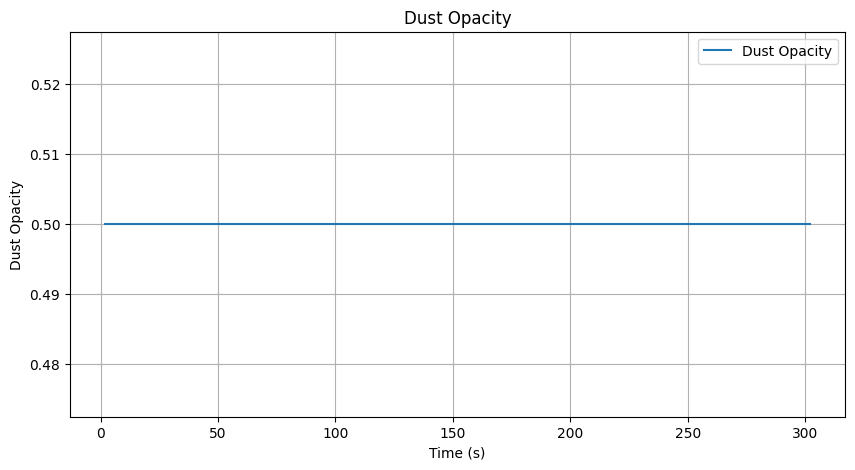

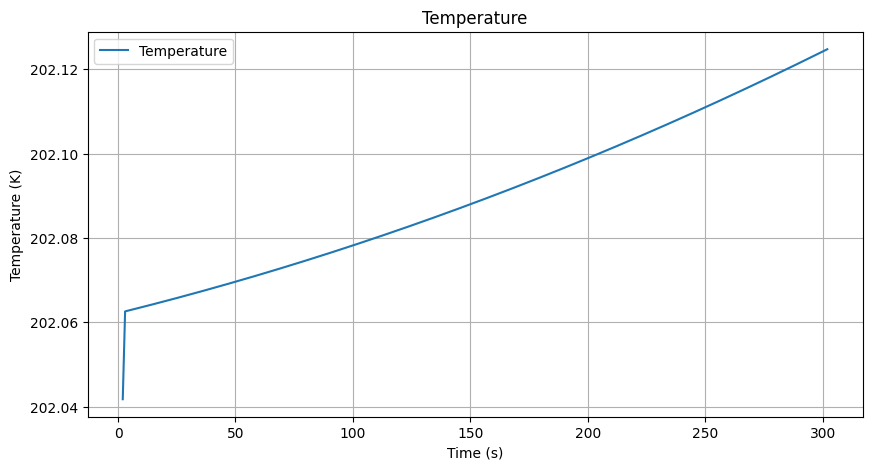

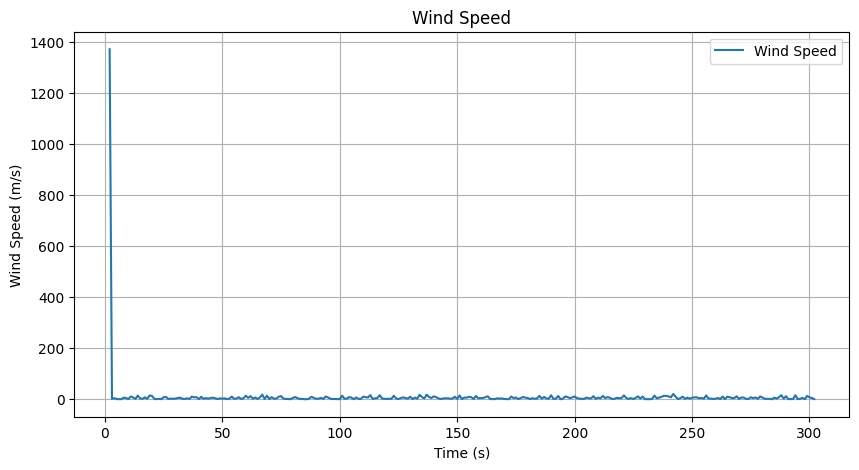

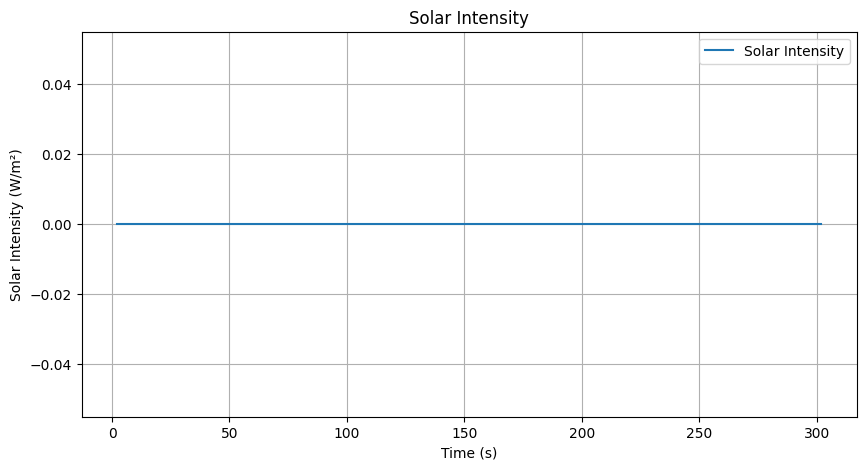

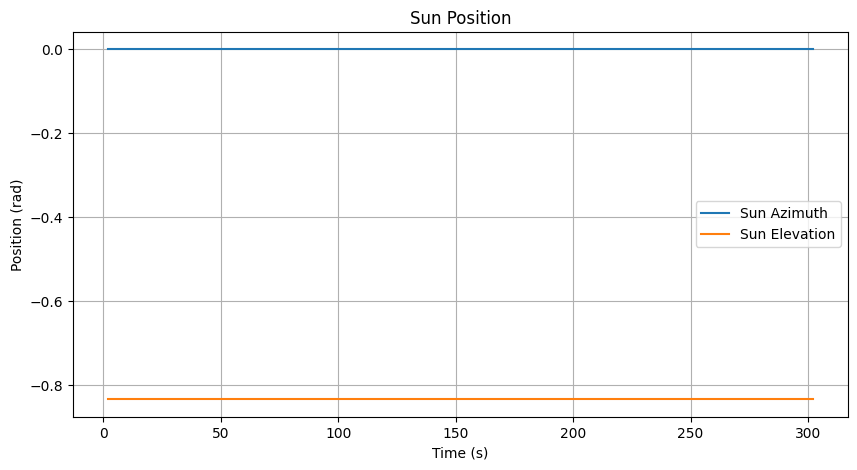

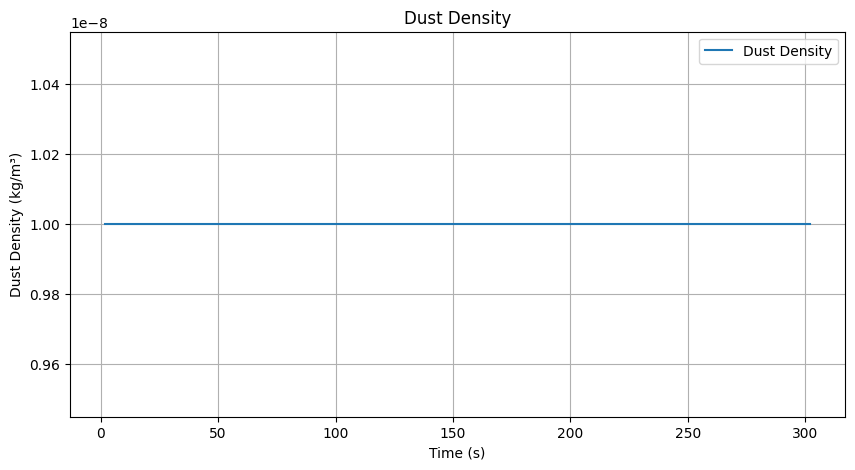

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(x=environment_df.index, y='dust_opacity_tau', data=environment_df, ax=ax, label='Dust Opacity')
plt.legend()
ax.set_title('Dust Opacity')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Dust Opacity')
plt.grid()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(x=environment_df.index, y='temperature_K', data=environment_df, ax=ax, label='Temperature')
plt.legend()
ax.set_title('Temperature')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Temperature (K)')
plt.grid()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(x=environment_df.index, y='wind_speed_m_per_s', data=environment_df, ax=ax, label='Wind Speed')
plt.legend()
ax.set_title('Wind Speed')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Wind Speed (m/s)')
plt.grid()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(x=environment_df.index, y='solar_intensity_W_per_m2', data=environment_df, ax=ax, label='Solar Intensity')
plt.legend()
ax.set_title('Solar Intensity')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Solar Intensity (W/m²)')
plt.grid()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(x=environment_df.index, y='sun_azimuth', data=environment_df, ax=ax, label='Sun Azimuth')
sns.lineplot(x=environment_df.index, y='sun_elevation', data=environment_df, ax=ax, label='Sun Elevation')
plt.legend()
ax.set_title('Sun Position')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Position (rad)')
plt.grid()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(x=environment_df.index, y='dust_density_kg_per_m3', data=environment_df, ax=ax, label='Dust Density')
plt.legend()
ax.set_title('Dust Density')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Dust Density (kg/m³)')
plt.grid()
plt.show()





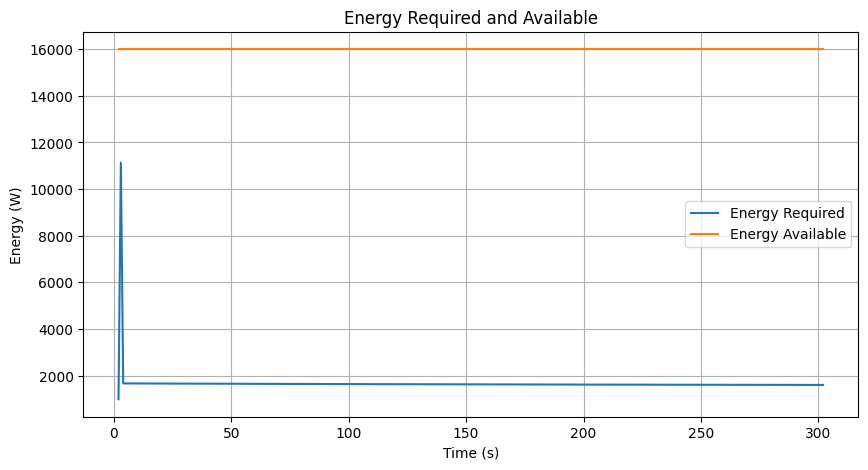

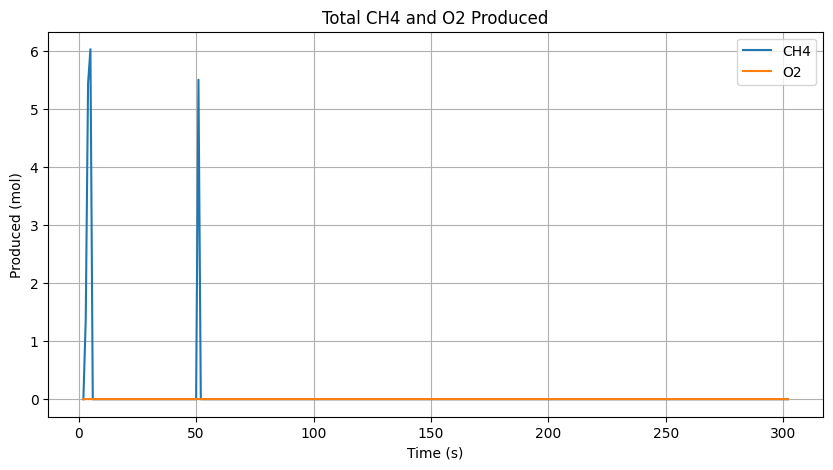

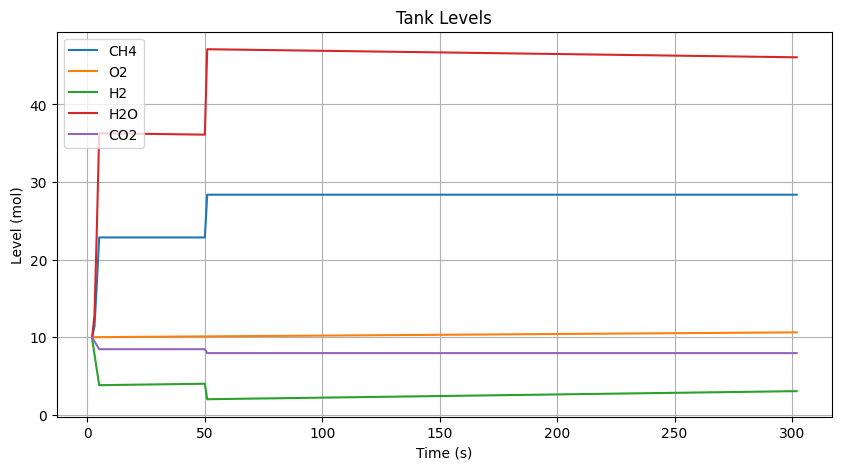

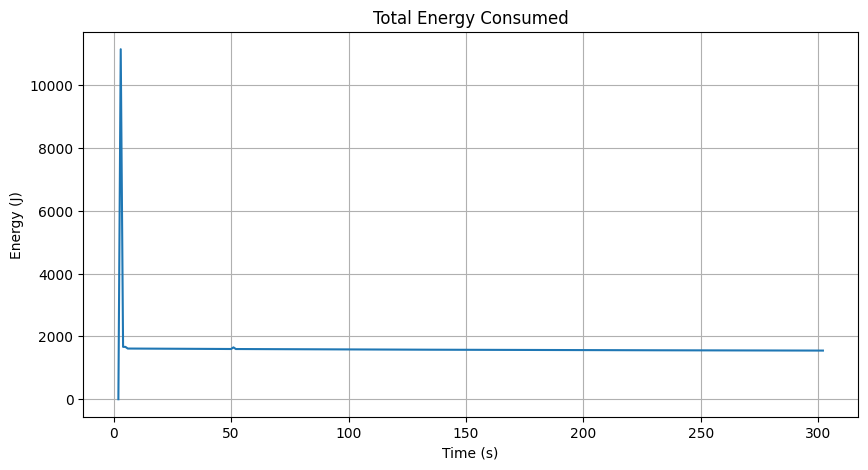

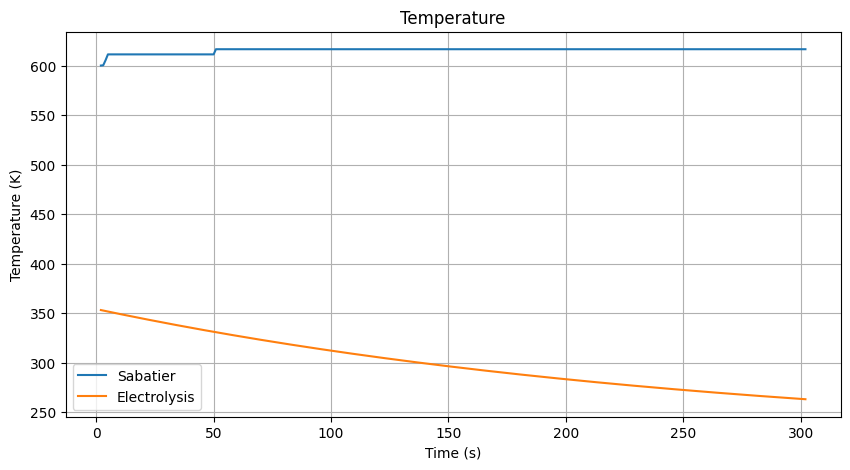

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(x=isru_plant_df.index, y='energy_required_W', data=isru_plant_df, ax=ax, label='Energy Required')
sns.lineplot(x=isru_plant_df.index, y='energy_available_W', data=isru_plant_df, ax=ax, label='Energy Available')
plt.legend()
ax.set_title('Energy Required and Available')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Energy (W)')
plt.grid()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(x=isru_plant_df.index, y='total_CH4_produced_mol', data=isru_plant_df, ax=ax, label='CH4')
sns.lineplot(x=isru_plant_df.index, y='total_O2_produced_mol', data=isru_plant_df, ax=ax, label='O2')
plt.legend()
ax.set_title('Total CH4 and O2 Produced')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Produced (mol)')
plt.grid()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(x=isru_plant_df.index, y='current_CH4_level_mol', data=isru_plant_df, ax=ax, label='CH4')
sns.lineplot(x=isru_plant_df.index, y='current_O2_level_mol', data=isru_plant_df, ax=ax, label='O2')
sns.lineplot(x=isru_plant_df.index, y='current_H2_level_mol', data=isru_plant_df, ax=ax, label='H2')
sns.lineplot(x=isru_plant_df.index, y='current_H2O_level_mol', data=isru_plant_df, ax=ax, label='H2O')
sns.lineplot(x=isru_plant_df.index, y='current_CO2_level_mol', data=isru_plant_df, ax=ax, label='CO2')
plt.legend()
ax.set_title('Tank Levels')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Level (mol)')
plt.grid()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(x=isru_plant_df.index, y='total_energy_consumed_J', data=isru_plant_df, ax=ax)
ax.set_title('Total Energy Consumed')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Energy (J)')
plt.grid()

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(x=isru_plant_df.index, y='sabatier_temperature_K', data=isru_plant_df, ax=ax, label='Sabatier')
sns.lineplot(x=isru_plant_df.index, y='electrolysis_temperature_K', data=isru_plant_df, ax=ax, label='Electrolysis')
plt.legend()
ax.set_title('Temperature')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Temperature (K)')
plt.grid()